<a href="https://colab.research.google.com/github/njwbilll/Tugas-2_scikit-learn-Cookbook-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/13_Deploying_scikit_learn_Models_in_Production.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 13: Deploying scikit-learn Models in Production

**Referensi:** scikit-learn Cookbook, Third Edition - John Sukup (Packt Publishing, 2025)

---

## Ringkasan Chapter

Chapter 13 membahas bagaimana membawa model machine learning dari lingkungan pengembangan ke lingkungan produksi yang sesungguhnya. Seperti yang dijelaskan dalam buku: *"Models must be deployed in compute environments that allow for scalability and high throughput while still maintaining predictive performance."* Chapter ini mencakup serialisasi model, penskalaan untuk beban produksi, pemantauan performa model dari waktu ke waktu, manajemen siklus hidup model, dan pengaturan pipeline deployment otomatis.

### Topik yang Dibahas:
1. Overview model deployment
2. Teknik serialisasi dan persistensi model (pickle dan joblib)
3. Penskalaan model untuk produksi (parallelism dan batch serving)
4. Pemantauan dan pembaruan model yang sudah di-deploy
5. Manajemen siklus hidup model (versioning dan metadata)
6. Pengaturan pipeline deployment

---

## Setup: Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(2024)
print("Library berhasil diimport.")

Library berhasil diimport.


---
## 1. Overview Model Deployment

### Penjelasan Teori

**Model deployment** adalah proses memindahkan model yang telah dilatih dari lingkungan pengembangan ke lingkungan produksi sehingga pengguna atau sistem lain dapat mengakses prediksinya secara nyata.

Deployment bukan sekadar menyimpan model ke dalam file. Proses ini mencakup beberapa aspek penting:

- **Packaging**: Menyiapkan model sebagai artefak yang dapat dipindahkan dan dijalankan di lingkungan lain.
- **Serving**: Menyajikan prediksi kepada sistem atau pengguna dengan latensi dan throughput yang sesuai.
- **Monitoring**: Memastikan model terus bekerja dengan baik seiring waktu karena data di dunia nyata selalu berubah.

**Metode serving yang umum:**
- **REST API**: Model dibungkus dalam endpoint HTTP, cocok untuk permintaan real-time satu per satu.
- **Batch pipeline**: Prediksi dilakukan secara massal pada banyak data sekaligus, efisien untuk proses non-real-time.
- **Serverless functions**: Model dipanggil sesuai kebutuhan tanpa server yang selalu aktif.

**Workflow dasar deployment:**
1. Latih model di lingkungan pengembangan.
2. Simpan model ke disk menggunakan serialisasi.
3. Load model di lingkungan produksi.
4. Verifikasi prediksi konsisten dengan model asli.
5. Sajikan prediksi kepada pengguna atau sistem downstream.

In [2]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from joblib import dump, load
import time

# Latih model sederhana
X, y = make_classification(
    n_samples=1000, n_features=20, random_state=2024
)
clf = LogisticRegression(max_iter=1000)
clf.fit(X, y)

print(f"Model berhasil dilatih.")
print(f"  Tipe model:     {clf.__class__.__name__}")
print(f"  Jumlah fitur:   {clf.n_features_in_}")
print(f"  Jumlah kelas:   {len(clf.classes_)}")
print(f"  Training score: {clf.score(X, y):.4f}")

Model berhasil dilatih.
  Tipe model:     LogisticRegression
  Jumlah fitur:   20
  Jumlah kelas:   2
  Training score: 0.8790


In [3]:
# Simpan model menggunakan joblib
dump(clf, "model.joblib")
print("Model berhasil disimpan ke 'model.joblib'.")

# Load model kembali (simulasi lingkungan produksi)
clf_loaded = load("model.joblib")
print("Model berhasil di-load dari disk.")

# Buat prediksi dengan model yang telah di-load
incoming = np.random.rand(5, 20)
predictions = clf_loaded.predict(incoming)
probabilities = clf_loaded.predict_proba(incoming)

print()
print("Prediksi pada 5 sampel baru:")
result_df = pd.DataFrame({
    'Prediksi Kelas': predictions,
    'Prob Kelas 0': probabilities[:, 0].round(4),
    'Prob Kelas 1': probabilities[:, 1].round(4)
})
display(result_df)

Model berhasil disimpan ke 'model.joblib'.
Model berhasil di-load dari disk.

Prediksi pada 5 sampel baru:


,Prediksi Kelas,Prob Kelas 0,Prob Kelas 1
0,1,0.1549,0.8451
1,1,0.0786,0.9214
2,1,0.1292,0.8708
3,1,0.1687,0.8313
4,1,0.1168,0.8832


In [4]:
# Verifikasi konsistensi: model asli vs model yang di-load
pred_original = clf.predict(X[:10])
pred_loaded   = clf_loaded.predict(X[:10])

is_identical = np.array_equal(pred_original, pred_loaded)

print("Verifikasi Konsistensi Prediksi:")
print(f"  Prediksi model asli:   {pred_original}")
print(f"  Prediksi model loaded: {pred_loaded}")
print(f"  Identik: {is_identical}")

# Perbandingan latensi: single vs batch
single_sample = np.random.rand(1, 20)
batch_samples = np.random.rand(1000, 20)

start = time.time()
for _ in range(100):
    clf_loaded.predict(single_sample)
time_single = (time.time() - start) / 100

start = time.time()
clf_loaded.predict(batch_samples)
time_batch = time.time() - start

print()
print("Perbandingan Latensi:")
print(f"  Single prediction (rata-rata 100x): {time_single*1000:.4f} ms")
print(f"  Batch prediction (1000 sampel):     {time_batch*1000:.4f} ms")
print(f"  Throughput batch vs single:         {(time_batch/1000)/(time_single):.4f}x lebih cepat per sampel")

Verifikasi Konsistensi Prediksi:
  Prediksi model asli:   [1 1 1 0 0 1 0 0 1 1]
  Prediksi model loaded: [1 1 1 0 0 1 0 0 1 1]
  Identik: True

Perbandingan Latensi:
  Single prediction (rata-rata 100x): 0.2649 ms
  Batch prediction (1000 sampel):     0.5171 ms
  Throughput batch vs single:         0.0020x lebih cepat per sampel


---
## 2. Teknik Serialisasi dan Persistensi

### Penjelasan Teori

**Serialisasi** adalah proses mengubah objek model (yang ada di memori) menjadi format byte stream yang dapat disimpan ke disk dan dipindahkan ke sistem lain. Ini adalah langkah wajib sebelum deployment karena setelah proses Python berakhir, model akan hilang dari memori.

**Dua metode utama untuk scikit-learn:**

**1. pickle (built-in Python):**
- Library bawaan Python untuk serialisasi objek Python secara umum.
- Bekerja untuk hampir semua estimator scikit-learn.
- Kurang optimal untuk array NumPy besar yang ada di dalam model (misalnya, bobot Random Forest).

**2. joblib (direkomendasikan untuk scikit-learn):**
- Dioptimalkan khusus untuk array NumPy berukuran besar.
- Mendukung kompresi untuk menghemat ruang disk.
- **Rekomendasi resmi scikit-learn** untuk menyimpan dan memuat model.

**Peringatan keamanan:**
Jangan pernah memuat file pickle atau joblib dari sumber yang tidak dipercaya. Format ini dapat mengeksekusi kode arbitrer saat di-load.

**Perhatian kompatibilitas versi:**
Model yang disimpan dengan versi scikit-learn tertentu mungkin tidak dapat dimuat dengan versi yang berbeda. Selalu catat versi library yang digunakan saat menyimpan model.

**Format alternatif:**
- **ONNX (Open Neural Network Exchange)**: Format portabel yang memungkinkan model dijalankan di lingkungan tanpa Python.
- **PMML (Predictive Model Markup Language)**: Format XML standar industri untuk model prediktif.

In [5]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
import pickle
from joblib import dump, load
import os

# Latih Random Forest (model dengan banyak array NumPy di dalamnya)
X_rf, y_rf = make_classification(
    n_samples=500, n_features=15, random_state=2024
)
rf = RandomForestClassifier(n_estimators=10, random_state=2024)
rf.fit(X_rf, y_rf)

print(f"Model Random Forest dilatih.")
print(f"  n_estimators: {rf.n_estimators}")
print(f"  n_features:   {rf.n_features_in_}")

Model Random Forest dilatih.
  n_estimators: 10
  n_features:   15


In [6]:
# Serialisasi dengan pickle
with open("rf.pkl", "wb") as f:
    pickle.dump(rf, f)

# Serialisasi dengan joblib
dump(rf, "rf.joblib")

# Ukuran file
size_pkl   = os.path.getsize("rf.pkl")
size_jbl   = os.path.getsize("rf.joblib")

print("Perbandingan Ukuran File:")
print(f"  pickle (.pkl):  {size_pkl:,} bytes")
print(f"  joblib (.jbl):  {size_jbl:,} bytes")

Perbandingan Ukuran File:
  pickle (.pkl):  58,307 bytes
  joblib (.jbl):  59,225 bytes


In [7]:
# Load dari pickle
with open("rf.pkl", "rb") as f:
    rf1 = pickle.load(f)

# Load dari joblib
rf2 = load("rf.joblib")

# Verifikasi konsistensi prediksi
assert np.array_equal(rf.predict(X_rf[:5]), rf1.predict(X_rf[:5])), \
    "Prediksi pickle tidak konsisten!"
assert np.array_equal(rf.predict(X_rf[:5]), rf2.predict(X_rf[:5])), \
    "Prediksi joblib tidak konsisten!"

print("Verifikasi Konsistensi:")
print(f"  Prediksi model asli:    {rf.predict(X_rf[:5])}")
print(f"  Prediksi via pickle:    {rf1.predict(X_rf[:5])}")
print(f"  Prediksi via joblib:    {rf2.predict(X_rf[:5])}")
print()
print("Semua prediksi identik. Serialisasi berhasil.")

Verifikasi Konsistensi:
  Prediksi model asli:    [0 1 0 1 0]
  Prediksi via pickle:    [0 1 0 1 0]
  Prediksi via joblib:    [0 1 0 1 0]

Semua prediksi identik. Serialisasi berhasil.


In [8]:
# Perbandingan kecepatan load
import time

start = time.time()
for _ in range(50):
    with open("rf.pkl", "rb") as f:
        pickle.load(f)
time_pkl = (time.time() - start) / 50

start = time.time()
for _ in range(50):
    load("rf.joblib")
time_jbl = (time.time() - start) / 50

comparison = pd.DataFrame({
    'Metode': ['pickle', 'joblib'],
    'Ukuran File (bytes)': [size_pkl, size_jbl],
    'Rata-rata Waktu Load (ms)': [
        round(time_pkl * 1000, 4),
        round(time_jbl * 1000, 4)
    ],
    'Rekomendasi scikit-learn': ['Tidak', 'Ya']
})
print("Perbandingan Metode Serialisasi:")
display(comparison.set_index('Metode'))

Perbandingan Metode Serialisasi:


,Ukuran File (bytes),Rata-rata Waktu Load (ms),Rekomendasi scikit-learn
Metode,,,
pickle,58307,2.0176,Tidak
joblib,59225,5.7874,Ya


---
## 3. Penskalaan Model untuk Produksi

### Penjelasan Teori

Dalam lingkungan produksi nyata, model sering menghadapi beban yang jauh lebih besar dari saat pengembangan: ribuan permintaan per detik, dataset yang terus bertambah, dan infrastruktur yang terdistribusi. Berikut adalah strategi penskalaan utama:

**Parallelisme dengan `n_jobs`:**
Banyak estimator scikit-learn mendukung parameter `n_jobs` yang memungkinkan pelatihan dan prediksi memanfaatkan beberapa core CPU secara paralel.
- `n_jobs=1`: Satu core (default).
- `n_jobs=-1`: Gunakan semua core yang tersedia.
- `n_jobs=4`: Gunakan tepat 4 core.

**Batch serving:**
Daripada memprediksi satu sampel per permintaan, kumpulkan permintaan menjadi batch lalu prediksi sekaligus. Ini memanfaatkan optimisasi linear algebra di NumPy dan menghasilkan throughput yang jauh lebih tinggi per satuan waktu.

**Incremental learning dengan `partial_fit`:**
Beberapa estimator seperti `SGDClassifier` mendukung `partial_fit`, yang memungkinkan model dilatih ulang pada batch data baru tanpa harus melatih ulang dari awal. Sangat berguna untuk data yang mengalir secara kontinu (streaming data).

**Dask sebagai backend paralel:**
Untuk komputasi terdistribusi di klaster, Dask dapat digunakan sebagai backend joblib alternatif, memungkinkan pelatihan dan prediksi di banyak mesin sekaligus.

In [9]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import time

# Dataset besar untuk benchmarking
X_big, y_big = make_classification(
    n_samples=2000, n_features=50, random_state=2024
)

print(f"Dataset benchmarking: {X_big.shape}")

# Latih model dengan semua core (n_jobs=-1)
clf_parallel = RandomForestClassifier(
    n_estimators=100, n_jobs=-1, random_state=2024
)

start = time.time()
clf_parallel.fit(X_big, y_big)
time_parallel = time.time() - start

print(f"Waktu pelatihan (n_jobs=-1): {time_parallel:.4f} detik")

Dataset benchmarking: (2000, 50)
Waktu pelatihan (n_jobs=-1): 2.9419 detik


In [10]:
# Benchmarking: single vs batch prediction
batch_sizes = [1, 10, 100, 500, 1000]
times_per_sample = []

for bs in batch_sizes:
    batch = np.random.rand(bs, 50)
    times = []
    for _ in range(20):
        start = time.time()
        clf_parallel.predict(batch)
        times.append(time.time() - start)
    times_per_sample.append(np.mean(times) / bs * 1000)  # ms per sampel

bench_df = pd.DataFrame({
    'Batch Size': batch_sizes,
    'Waktu per Sampel (ms)': [round(t, 6) for t in times_per_sample]
})
print("Benchmarking Latensi per Sampel:")
display(bench_df.set_index('Batch Size'))

print()
print("Kesimpulan: Batch prediction secara signifikan lebih efisien per sampel")
print("karena overhead per-call dibagi ke lebih banyak sampel.")

Benchmarking Latensi per Sampel:


,Waktu per Sampel (ms)
Batch Size,
1,48.542058
10,5.606290
100,0.549842
500,0.144803
1000,0.106183



Kesimpulan: Batch prediction secara signifikan lebih efisien per sampel
karena overhead per-call dibagi ke lebih banyak sampel.


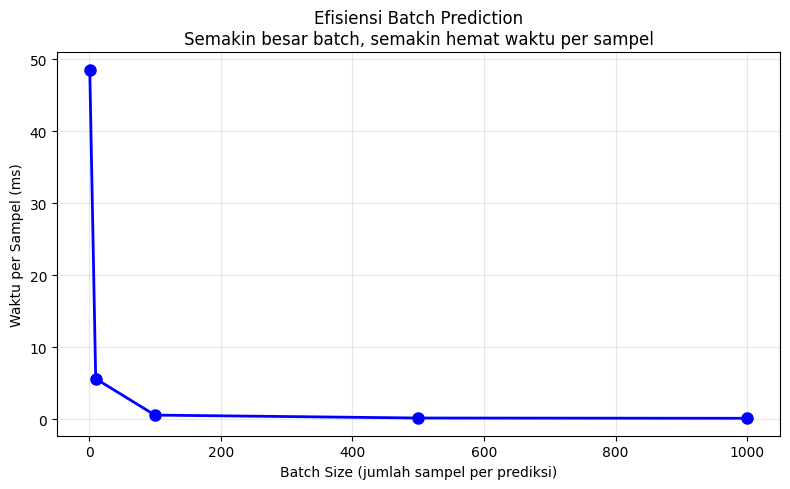

In [11]:
# Visualisasi: waktu per sampel vs batch size
plt.figure(figsize=(8, 5))
plt.plot(batch_sizes, times_per_sample, 'b-o', lw=2, markersize=8)
plt.xlabel('Batch Size (jumlah sampel per prediksi)')
plt.ylabel('Waktu per Sampel (ms)')
plt.title('Efisiensi Batch Prediction\n'
          'Semakin besar batch, semakin hemat waktu per sampel')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Cross-validation paralel
cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=50, random_state=2024),
    X_big, y_big, cv=5, n_jobs=-1
)

print("Cross-validation Paralel (n_jobs=-1):")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  Mean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"  Std CV Accuracy:  {np.std(cv_scores):.4f}")

Cross-validation Paralel (n_jobs=-1):
  Fold 1: 0.8875
  Fold 2: 0.8625
  Fold 3: 0.8700
  Fold 4: 0.8975
  Fold 5: 0.8575
  Mean CV Accuracy: 0.8750
  Std CV Accuracy:  0.0152


---
## 4. Pemantauan dan Pembaruan Model yang Sudah Di-Deploy

### Penjelasan Teori

Setelah model berjalan di produksi, performa model akan **menurun secara alami seiring waktu**. Fenomena ini disebut **model drift** atau **data drift** dan terjadi karena:

- **Data drift (covariate shift)**: Distribusi fitur input berubah dari waktu ke waktu.
- **Concept drift**: Hubungan antara fitur dan target berubah (misalnya, perilaku pengguna yang berubah).
- **Label drift**: Distribusi kelas target berubah.

**Strategi pemantauan:**
- Pantau akurasi model pada setiap batch data baru.
- Monitor statistik distribusi fitur (mean, std, skewness) dari waktu ke waktu.
- Gunakan uji statistik (KS test, chi-square) untuk mendeteksi pergeseran distribusi.

**Strategi pembaruan model:**
- **Full retraining**: Latih ulang model dari awal dengan data terbaru. Terbaik jika data cukup dan ada jadwal rutin.
- **Incremental learning**: Gunakan `partial_fit` untuk memperbarui model dengan data baru tanpa melatih dari awal. Cocok untuk data streaming.
- **Retraining otomatis**: Trigger retraining ketika performa turun di bawah threshold yang ditentukan.

**Konsep CI/CD/CT (Continuous Integration / Continuous Deployment / Continuous Training):**
Pipeline CI/CD yang biasa dikenal dalam rekayasa perangkat lunak diperluas dengan CT untuk menangani siklus hidup model ML yang membutuhkan pelatihan ulang berkala.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import make_classification

# Simulasi data awal (historical)
X_train_hist, y_train_hist = make_classification(
    n_samples=500, n_features=10, random_state=2024
)

# Simulasi data produksi yang mengalir (streaming)
X_prod, y_prod = make_classification(
    n_samples=200, n_features=10, random_state=2025
)
stream_batches = np.array_split(X_prod, 4)
stream_labels  = np.array_split(y_prod, 4)

print("Setup Simulasi Monitoring:")
print(f"  Data historis:   {X_train_hist.shape}")
print(f"  Data produksi:   {X_prod.shape}")
print(f"  Jumlah batch:    {len(stream_batches)}")
for i, b in enumerate(stream_batches, 1):
    print(f"  Batch {i}: {b.shape[0]} sampel")

Setup Simulasi Monitoring:
  Data historis:   (500, 10)
  Data produksi:   (200, 10)
  Jumlah batch:    4
  Batch 1: 50 sampel
  Batch 2: 50 sampel
  Batch 3: 50 sampel
  Batch 4: 50 sampel


In [14]:
# Latih model inkremental dengan SGDClassifier
clf_sgd = SGDClassifier(
    loss="log_loss", random_state=2024, warm_start=True
)
clf_sgd.partial_fit(
    X_train_hist, y_train_hist,
    classes=np.unique(y_train_hist)
)

# Monitor akurasi pada setiap batch baru
batch_scores = []
THRESHOLD = 0.60  # batas minimum akurasi

print("Monitoring Performa per Batch:")
for i, (xb, yb) in enumerate(zip(stream_batches, stream_labels), 1):
    y_pred_batch = clf_sgd.predict(xb)
    acc = np.mean(y_pred_batch == yb)
    batch_scores.append(acc)
    status = "OK" if acc >= THRESHOLD else "PERINGATAN - di bawah threshold"
    print(f"  Batch {i}: Accuracy = {acc:.4f}  [{status}]")

print()
# Trigger retraining jika akurasi minimum turun di bawah threshold
if min(batch_scores) < THRESHOLD:
    print(f"Akurasi minimum ({min(batch_scores):.4f}) di bawah threshold ({THRESHOLD}).")
    print("Memicu retraining dengan data produksi terbaru...")
    clf_sgd.partial_fit(X_prod, y_prod)
    print("Retraining selesai.")
else:
    print("Semua batch di atas threshold. Tidak perlu retraining.")

Monitoring Performa per Batch:
  Batch 1: Accuracy = 0.3800  [PERINGATAN - di bawah threshold]
  Batch 2: Accuracy = 0.3000  [PERINGATAN - di bawah threshold]
  Batch 3: Accuracy = 0.3600  [PERINGATAN - di bawah threshold]
  Batch 4: Accuracy = 0.3800  [PERINGATAN - di bawah threshold]

Akurasi minimum (0.3000) di bawah threshold (0.6).
Memicu retraining dengan data produksi terbaru...
Retraining selesai.


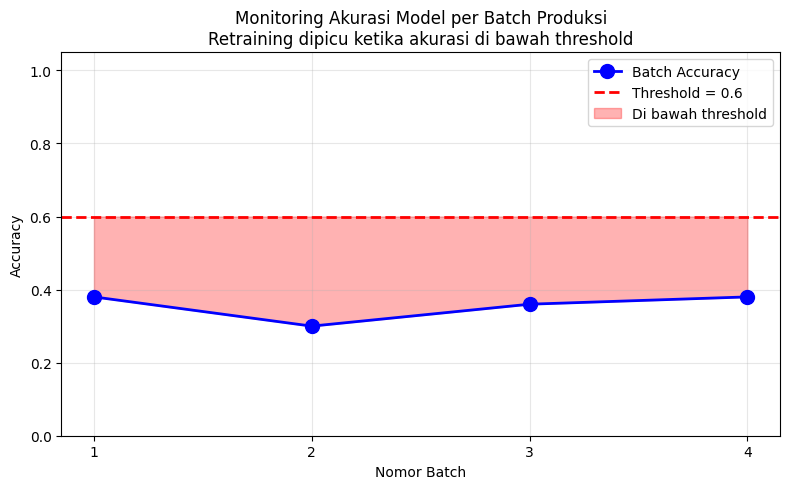

In [15]:
# Visualisasi tren akurasi per batch
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(batch_scores) + 1), batch_scores,
    'b-o', lw=2, markersize=10, label='Batch Accuracy'
)
plt.axhline(
    THRESHOLD, color='red', linestyle='--', lw=2,
    label=f'Threshold = {THRESHOLD}'
)
plt.fill_between(
    range(1, len(batch_scores) + 1),
    batch_scores, THRESHOLD,
    where=[s < THRESHOLD for s in batch_scores],
    alpha=0.3, color='red', label='Di bawah threshold'
)
plt.xlabel('Nomor Batch')
plt.ylabel('Accuracy')
plt.title('Monitoring Akurasi Model per Batch Produksi\n'
          'Retraining dipicu ketika akurasi di bawah threshold')
plt.legend()
plt.xticks(range(1, len(batch_scores) + 1))
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Manajemen Siklus Hidup Model

### Penjelasan Teori

**Model lifecycle management** adalah praktik untuk memastikan model tetap dapat diandalkan, direproduksi, dan dipelihara sepanjang masa pakainya. Ini mencakup:

**Versioning (Penomoran versi):**
Setiap model yang disimpan harus memiliki nomor versi yang jelas (misalnya `v1.0`, `v1.1`, `v2.0`). Ini memungkinkan rollback ke versi sebelumnya jika versi terbaru bermasalah.

**Metadata snapshot:**
Bersama model, simpan juga metadata yang mencatat:
- Versi model
- Versi scikit-learn dan library lain yang digunakan
- Tanggal pelatihan
- Parameter model
- Performa model pada validation set

**Mengapa ini penting:**
- Jika terjadi permasalahan di produksi, kita bisa langsung rollback ke versi sebelumnya.
- Ketika scikit-learn diupgrade, kita bisa memverifikasi apakah model lama masih kompatibel.
- Audit trail yang jelas untuk kepatuhan regulasi (compliance) di industri yang diatur ketat.

**Alat MLOps:**
Untuk skala yang lebih besar, gunakan platform seperti MLflow atau BentoML yang mengotomatiskan penyimpanan artefak, tracking metadata, dan kemampuan rollback. Meskipun begitu, praktik snapshotting manual tetap penting sebagai lapisan keamanan tambahan.

In [16]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification, load_iris
from sklearn.metrics import accuracy_score
from joblib import dump, load
import json
import os
from datetime import datetime

# Latih model
X_lc2, y_lc2 = make_classification(
    n_samples=800, n_features=20, random_state=2024
)
clf_lc = RandomForestClassifier(n_estimators=50, random_state=2024)
clf_lc.fit(X_lc2, y_lc2)

# Tentukan versi model
version = "v1.0"

# Simpan artefak model dengan nama berversi
model_path = f"rf_{version}.joblib"
dump(clf_lc, model_path)
print(f"Model disimpan: {model_path}")

Model disimpan: rf_v1.0.joblib


In [17]:
# Simpan metadata pelatihan
import sklearn

meta = {
    "version":          version,
    "tanggal_latih":    datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "sklearn_version":  sklearn.__version__,
    "numpy_version":    str(np.__version__),
    "model_class":      clf_lc.__class__.__name__,
    "n_estimators":     clf_lc.n_estimators,
    "n_features":       int(clf_lc.n_features_in_),
    "training_samples": X_lc2.shape[0]
}

meta_path = f"rf_{version}_metadata.json"
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print(f"Metadata disimpan: {meta_path}")
print()
print("Isi Metadata:")
for k, v in meta.items():
    print(f"  {k}: {v}")

Metadata disimpan: rf_v1.0_metadata.json

Isi Metadata:
  version: v1.0
  tanggal_latih: 2026-06-24 09:00:29
  sklearn_version: 1.6.1
  numpy_version: 2.0.2
  model_class: RandomForestClassifier
  n_estimators: 50
  n_features: 20
  training_samples: 800


In [18]:
# Simpan snapshot performa validasi
X_val_snap, y_val_snap = load_iris(return_X_y=True)
# Gunakan predict pada dataset yang berbeda untuk mensimulasikan cross-domain check
# Catatan: dalam praktik nyata, gunakan validation set dari distribusi yang sama
val_acc = accuracy_score(y_lc2[:100], clf_lc.predict(X_lc2[:100]))

val_path = f"rf_{version}_val.txt"
with open(val_path, "w") as f:
    f.write(f"version: {version}\n")
    f.write(f"val_accuracy: {val_acc:.4f}\n")
    f.write(f"tanggal: {datetime.now().strftime('%Y-%m-%d')}\n")

print(f"Snapshot validasi disimpan: {val_path}")
print(f"  Validation Accuracy ({version}): {val_acc:.4f}")

# Ringkasan file artefak
artefak_df = pd.DataFrame([
    {'File': model_path,
     'Ukuran (bytes)': os.path.getsize(model_path),
     'Deskripsi': 'Model artefak (joblib)'},
    {'File': meta_path,
     'Ukuran (bytes)': os.path.getsize(meta_path),
     'Deskripsi': 'Metadata pelatihan (JSON)'},
    {'File': val_path,
     'Ukuran (bytes)': os.path.getsize(val_path),
     'Deskripsi': 'Snapshot performa validasi (TXT)'}
])
print()
print("Ringkasan Artefak yang Disimpan:")
display(artefak_df.set_index('File'))

Snapshot validasi disimpan: rf_v1.0_val.txt
  Validation Accuracy (v1.0): 1.0000

Ringkasan Artefak yang Disimpan:


,Ukuran (bytes),Deskripsi
File,,
rf_v1.0.joblib,409785,Model artefak (joblib)
rf_v1.0_metadata.json,235,Metadata pelatihan (JSON)
rf_v1.0_val.txt,55,Snapshot performa validasi (TXT)


In [19]:
# Simulasi rollback: load versi sebelumnya
clf_loaded_v1 = load(f"rf_{version}.joblib")
with open(meta_path) as f:
    meta_loaded = json.load(f)

print("Simulasi Rollback ke Versi Sebelumnya:")
print(f"  Model yang di-load: {meta_loaded['model_class']} {meta_loaded['version']}")
print(f"  Dilatih pada: {meta_loaded['tanggal_latih']}")
print(f"  scikit-learn: {meta_loaded['sklearn_version']}")
print(f"  Prediksi rollback: {clf_loaded_v1.predict(X_lc2[:5])}")
print(f"  Prediksi original: {clf_lc.predict(X_lc2[:5])}")
print(f"  Identik: {np.array_equal(clf_loaded_v1.predict(X_lc2[:5]), clf_lc.predict(X_lc2[:5]))}")

Simulasi Rollback ke Versi Sebelumnya:
  Model yang di-load: RandomForestClassifier v1.0
  Dilatih pada: 2026-06-24 09:00:29
  scikit-learn: 1.6.1
  Prediksi rollback: [0 1 1 1 0]
  Prediksi original: [0 1 1 1 0]
  Identik: True


---
## 6. Pengaturan Pipeline Deployment

### Penjelasan Teori

**Pipeline deployment** mengintegrasikan preprocessing, model, dan logika validasi ke dalam satu artefak tunggal yang dapat di-deploy secara konsisten ke berbagai lingkungan. Manfaat utamanya:

**Konsistensi preprocessing:**
Jika preprocessing (misalnya StandardScaler) tidak dimasukkan ke dalam pipeline yang sama dengan model, ada risiko **training-serving skew**: data di production diproses secara berbeda dari saat training, menghasilkan prediksi yang salah.

**Keuntungan Pipeline scikit-learn:**
- Preprocessing dan model menjadi satu artefak yang tidak dapat dipisahkan.
- `.fit()` pada pipeline otomatis melatih semua step secara berurutan.
- `.predict()` pada pipeline otomatis menerapkan transformasi sebelum prediksi.
- Lebih mudah di-serialize sebagai satu unit.

**Deployment gating:**
Sebelum model dipromosikan ke production, terapkan pengecekan otomatis (CI check) yang memvalidasi bahwa model baru memenuhi threshold performa minimum. Jika tidak, deployment dibatalkan dan tim mendapat notifikasi untuk meninjau ulang.

**CI/CD/CT Workflow:**
1. Developer melatih model baru.
2. CI pipeline otomatis menguji model pada validation set.
3. Jika performa di atas threshold, model dipromosikan ke staging.
4. Setelah pengujian lanjutan, model dipromosikan ke production.
5. Sistem monitoring memantau performa di production.
6. Jika performa turun, CT pipeline memicu retraining otomatis.

In [20]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from joblib import dump, load

# Dataset
X_pipe, y_pipe = make_classification(
    n_samples=500, n_features=10, random_state=2024
)
X_pipe_tr, X_pipe_te, y_pipe_tr, y_pipe_te = train_test_split(
    X_pipe, y_pipe, test_size=0.2, random_state=2024
)

# Buat pipeline: preprocessing + model
pipe = Pipeline([
    ("scale", StandardScaler()),
    ("clf",   LogisticRegression(max_iter=1000, random_state=2024))
])
pipe.fit(X_pipe_tr, y_pipe_tr)

train_acc = pipe.score(X_pipe_tr, y_pipe_tr)
test_acc  = pipe.score(X_pipe_te, y_pipe_te)

print("Pipeline: StandardScaler + LogisticRegression")
print(f"  Training Accuracy: {train_acc:.4f}")
print(f"  Test Accuracy:     {test_acc:.4f}")

Pipeline: StandardScaler + LogisticRegression
  Training Accuracy: 0.9100
  Test Accuracy:     0.9000


In [21]:
# Simpan pipeline sebagai satu artefak
dump(pipe, "pipeline.joblib")
print("Pipeline disimpan ke 'pipeline.joblib'.")

# Load pipeline di lingkungan produksi (simulasi)
prod_pipe = load("pipeline.joblib")
print("Pipeline di-load dari disk.")
print()

# Verifikasi prediksi konsisten
pred_original = pipe.predict(X_pipe_te[:5])
pred_loaded   = prod_pipe.predict(X_pipe_te[:5])
print(f"Prediksi pipeline asli:    {pred_original}")
print(f"Prediksi pipeline loaded:  {pred_loaded}")
print(f"Identik: {np.array_equal(pred_original, pred_loaded)}")

Pipeline disimpan ke 'pipeline.joblib'.
Pipeline di-load dari disk.

Prediksi pipeline asli:    [1 1 0 0 1]
Prediksi pipeline loaded:  [1 1 0 0 1]
Identik: True


In [22]:
# Simulasi CI/CD check: deployment gating
DEPLOY_THRESHOLD = 0.80

# Simulasi data validasi yang datang dari sistem CI
X_ci = np.random.rand(100, 10)
y_ci = np.random.randint(0, 2, 100)

val_acc_ci = accuracy_score(y_ci, prod_pipe.predict(X_ci))

print("=" * 50)
print("CI/CD Deployment Gate Check")
print("=" * 50)
print(f"  Validation Accuracy: {val_acc_ci:.4f}")
print(f"  Threshold minimum:   {DEPLOY_THRESHOLD}")
print()

if val_acc_ci > DEPLOY_THRESHOLD:
    print("STATUS: LULUS - Model dipromosikan ke production.")
else:
    print("STATUS: GAGAL - Deployment dibatalkan. Tinjau model sebelum deploy.")

CI/CD Deployment Gate Check
  Validation Accuracy: 0.4200
  Threshold minimum:   0.8

STATUS: GAGAL - Deployment dibatalkan. Tinjau model sebelum deploy.


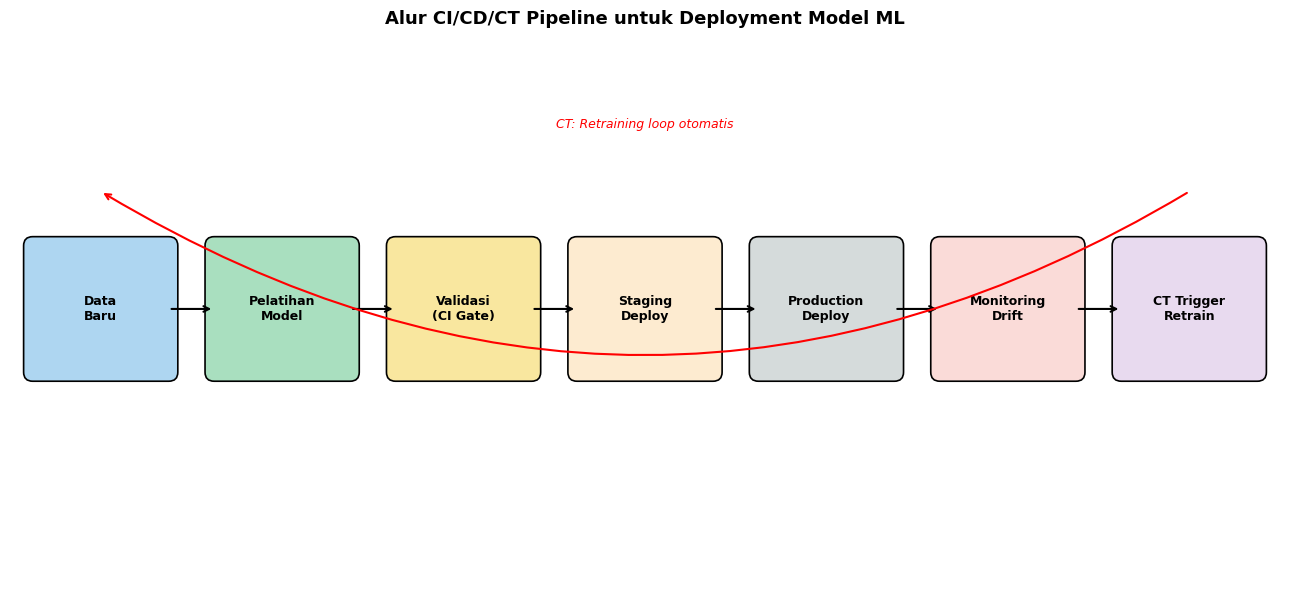

In [23]:
# Visualisasi diagram alur CI/CD/CT
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 6)
ax.axis('off')

steps = [
    (1,   3.0, 'Data\nBaru',         '#AED6F1'),
    (3,   3.0, 'Pelatihan\nModel',   '#A9DFBF'),
    (5,   3.0, 'Validasi\n(CI Gate)', '#F9E79F'),
    (7,   3.0, 'Staging\nDeploy',    '#FDEBD0'),
    (9,   3.0, 'Production\nDeploy', '#D5DBDB'),
    (11,  3.0, 'Monitoring\nDrift',  '#FADBD8'),
    (13,  3.0, 'CT Trigger\nRetrain', '#E8DAEF'),
]

for (x, y, label, color) in steps:
    rect = mpatches.FancyBboxPatch(
        (x - 0.75, y - 0.7), 1.5, 1.4,
        boxstyle="round,pad=0.1",
        facecolor=color, edgecolor='black', linewidth=1.2
    )
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center', fontsize=9, fontweight='bold')

# Panah antar step
arrow_xs = [1.75, 3.75, 5.75, 7.75, 9.75, 11.75]
for ax_x in arrow_xs:
    ax.annotate("",
                xy=(ax_x + 0.5, 3.0), xytext=(ax_x, 3.0),
                arrowprops=dict(arrowstyle="->", lw=1.5, color='black'))

# Panah feedback loop (CT ke Data Baru)
ax.annotate("",
            xy=(1.0, 4.3), xytext=(13.0, 4.3),
            arrowprops=dict(
                arrowstyle="->", lw=1.5, color='red',
                connectionstyle="arc3,rad=-0.3"
            ))
ax.text(7, 5.0, 'CT: Retraining loop otomatis',
        ha='center', color='red', fontsize=9, style='italic')

ax.set_title('Alur CI/CD/CT Pipeline untuk Deployment Model ML',
             fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

---
## 7. Latihan Komprehensif: Pipeline Deployment Lengkap

### Deskripsi

Latihan ini menggabungkan semua konsep deployment: membuat pipeline, menyimpannya, memuat ulang, memvalidasi, memantau batch, dan melakukan retraining inkremental jika performa menurun.

In [24]:
# Exercise 1: Simpan dan muat ulang pipeline untuk deployment
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from joblib import dump, load
import numpy as np
import json
from datetime import datetime
import sklearn

# 1. Latih pipeline
X_ex, y_ex = make_classification(
    n_samples=600, n_features=12,
    n_informative=8, random_state=2024
)
X_ex_tr, X_ex_te, y_ex_tr, y_ex_te = train_test_split(
    X_ex, y_ex, test_size=0.25, random_state=2024, stratify=y_ex
)

pipe_ex = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(C=1.0, max_iter=1000, random_state=2024))
])
pipe_ex.fit(X_ex_tr, y_ex_tr)

# 2. Simpan pipeline dan metadata
VERSION = "v1.0"
dump(pipe_ex, f"exercise_pipeline_{VERSION}.joblib")

meta_ex = {
    "version":          VERSION,
    "tanggal_latih":    datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "sklearn_version":  sklearn.__version__,
    "steps":            [s[0] for s in pipe_ex.steps],
    "C_parameter":      pipe_ex.named_steps['clf'].C,
    "train_accuracy":   round(pipe_ex.score(X_ex_tr, y_ex_tr), 4),
    "val_accuracy":     round(pipe_ex.score(X_ex_te, y_ex_te), 4)
}
with open(f"exercise_pipeline_{VERSION}_meta.json", "w") as f:
    json.dump(meta_ex, f, indent=2)

# 3. Load dan buat prediksi
pipe_prod = load(f"exercise_pipeline_{VERSION}.joblib")
y_pred_ex = pipe_prod.predict(X_ex_te)

print(f"Pipeline {VERSION} berhasil disimpan dan di-load.")
print(f"Training Accuracy: {meta_ex['train_accuracy']}")
print(f"Val Accuracy:      {meta_ex['val_accuracy']}")
print()
print("Classification Report:")
print(classification_report(
    y_ex_te, y_pred_ex,
    target_names=['Kelas 0', 'Kelas 1']
))

Pipeline v1.0 berhasil disimpan dan di-load.
Training Accuracy: 0.8156
Val Accuracy:      0.8133

Classification Report:
              precision    recall  f1-score   support

     Kelas 0       0.85      0.76      0.80        75
     Kelas 1       0.78      0.87      0.82        75

    accuracy                           0.81       150
   macro avg       0.82      0.81      0.81       150
weighted avg       0.82      0.81      0.81       150



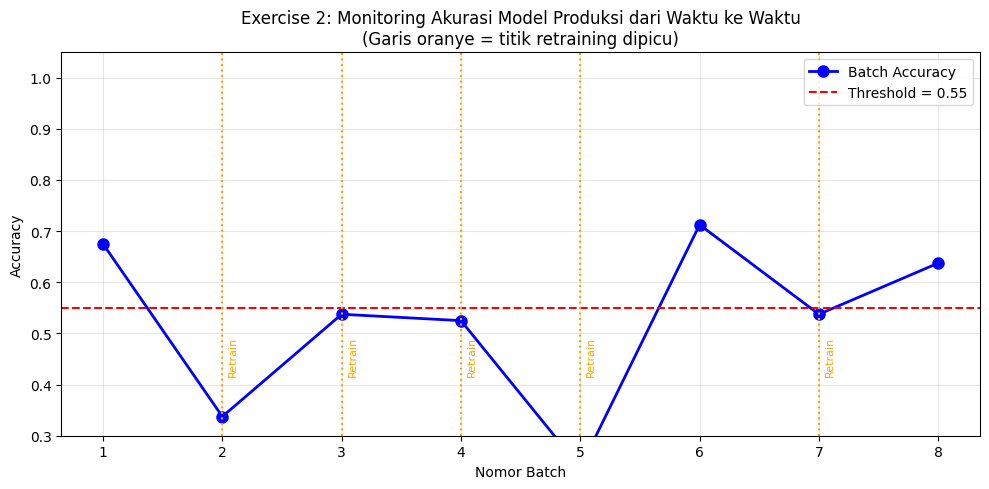

Akurasi per batch: [np.float64(0.675), np.float64(0.3375), np.float64(0.5375), np.float64(0.525), np.float64(0.2375), np.float64(0.7125), np.float64(0.5375), np.float64(0.6375)]
Retraining dipicu pada batch ke: [2, 3, 4, 5, 7].


In [25]:
# Exercise 2: Monitoring akurasi model dari waktu ke waktu
from sklearn.linear_model import SGDClassifier
import matplotlib.pyplot as plt

# Simulasi 8 batch produksi dengan drift bertahap
np.random.seed(42)
n_batches = 8

clf_monitor = SGDClassifier(loss="log_loss", random_state=2024)
# Inisialisasi classes di iterasi pertama
X_init, y_init = make_classification(
    n_samples=300, n_features=10, random_state=2024
)
clf_monitor.partial_fit(X_init, y_init, classes=np.array([0, 1]))

DEPLOY_THRESH = 0.55
batch_accs    = []
retrain_flags = []

for i in range(n_batches):
    # Simulasi drift: noise meningkat setiap batch
    noise_factor = 1 + i * 0.3
    X_b, y_b = make_classification(
        n_samples=80, n_features=10,
        random_state=100 + i * 7
    )
    X_b_noisy = X_b + np.random.normal(0, noise_factor * 0.3, X_b.shape)

    acc = np.mean(clf_monitor.predict(X_b_noisy) == y_b)
    batch_accs.append(acc)

    if acc < DEPLOY_THRESH:
        clf_monitor.partial_fit(X_b_noisy, y_b)
        retrain_flags.append(i + 1)

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, n_batches + 1), batch_accs, 'b-o', lw=2, markersize=8, label='Batch Accuracy')
ax.axhline(DEPLOY_THRESH, color='red', linestyle='--', lw=1.5, label=f'Threshold = {DEPLOY_THRESH}')
for rf in retrain_flags:
    ax.axvline(rf, color='orange', linestyle=':', lw=1.5)
    ax.text(rf + 0.05, 0.42, 'Retrain', color='orange', fontsize=8, rotation=90)
ax.set_xlabel('Nomor Batch')
ax.set_ylabel('Accuracy')
ax.set_title('Exercise 2: Monitoring Akurasi Model Produksi dari Waktu ke Waktu\n'
             '(Garis oranye = titik retraining dipicu)')
ax.legend()
ax.set_xticks(range(1, n_batches + 1))
ax.set_ylim(0.3, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Akurasi per batch: {[round(a, 4) for a in batch_accs]}")
print(f"Retraining dipicu pada batch ke: {retrain_flags if retrain_flags else 'Tidak ada'}.")

In [26]:
# Exercise 3: Deployment check otomatis dengan threshold validasi
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from joblib import dump, load
from sklearn.metrics import accuracy_score

def deploy_check(pipeline, X_val, y_val, threshold=0.80, label="Model"):
    """Fungsi CI check: validasi dan putuskan apakah model layak di-deploy."""
    acc = accuracy_score(y_val, pipeline.predict(X_val))
    status = "LULUS" if acc >= threshold else "GAGAL"
    print(f"\n{'='*50}")
    print(f"Deployment Gate Check - {label}")
    print(f"{'='*50}")
    print(f"  Validation Accuracy: {acc:.4f}")
    print(f"  Threshold:           {threshold}")
    print(f"  Status:              {status}")
    if acc >= threshold:
        print(f"  Tindakan: Model dipromosikan ke production.")
    else:
        print(f"  Tindakan: Deployment dibatalkan. Tinjau model.")
    return acc >= threshold

# Buat dua versi model: satu yang cukup baik, satu yang kurang baik
X_d, y_d = make_classification(
    n_samples=500, n_features=10, random_state=2024
)
X_d_tr, X_d_te, y_d_tr, y_d_te = train_test_split(
    X_d, y_d, test_size=0.2, random_state=2024
)

# Model baik: dilatih dengan data yang cukup
pipe_good = Pipeline([
    ("scale", StandardScaler()),
    ("clf",   LogisticRegression(C=1.0, max_iter=1000, random_state=2024))
])
pipe_good.fit(X_d_tr, y_d_tr)
dump(pipe_good, "pipe_good.joblib")

# Model buruk: sengaja dilatih dengan sangat sedikit data
pipe_poor = Pipeline([
    ("scale", StandardScaler()),
    ("clf",   LogisticRegression(C=0.0001, max_iter=100, random_state=2024))
])
pipe_poor.fit(X_d_tr[:20], y_d_tr[:20])
dump(pipe_poor, "pipe_poor.joblib")

# CI Check untuk kedua model
pipe_good_loaded = load("pipe_good.joblib")
pipe_poor_loaded = load("pipe_poor.joblib")

result_good = deploy_check(pipe_good_loaded, X_d_te, y_d_te, threshold=0.80, label="Model Baik")
result_poor = deploy_check(pipe_poor_loaded, X_d_te, y_d_te, threshold=0.80, label="Model Buruk")


Deployment Gate Check - Model Baik
  Validation Accuracy: 0.9000
  Threshold:           0.8
  Status:              LULUS
  Tindakan: Model dipromosikan ke production.

Deployment Gate Check - Model Buruk
  Validation Accuracy: 0.4600
  Threshold:           0.8
  Status:              GAGAL
  Tindakan: Deployment dibatalkan. Tinjau model.


---
## Ringkasan Chapter 13

| Konsep | Kelas/Fungsi | Deskripsi |
|--------|--------------|-----------|
| Menyimpan model | `joblib.dump()` | Serialisasi model ke disk (direkomendasikan) |
| Memuat model | `joblib.load()` | Load model dari disk ke memori |
| Serialisasi alternatif | `pickle.dump/load()` | Built-in Python, kurang optimal untuk array besar |
| Parallelisme | `n_jobs=-1` | Gunakan semua CPU core untuk training/prediksi |
| Incremental learning | `SGDClassifier.partial_fit()` | Update model dengan data baru tanpa retrain penuh |
| Pipeline terintegrasi | `Pipeline([steps])` | Gabungkan preprocessing dan model jadi satu artefak |
| Deployment gating | `accuracy_score()` + threshold | Validasi otomatis sebelum model masuk production |

### Poin Kunci untuk Diingat:

1. **Gunakan joblib, bukan pickle**, untuk menyimpan model scikit-learn karena joblib dioptimalkan untuk array NumPy berukuran besar yang ada di dalam model.

2. **Selalu simpan preprocessing dalam satu Pipeline** bersama model untuk menghindari training-serving skew, yaitu kondisi di mana data produksi diproses secara berbeda dari saat training.

3. **Batch prediction selalu lebih efisien** daripada single prediction per permintaan karena overhead per-call dibagi ke lebih banyak sampel.

4. **Model drift adalah keniscayaan**, bukan pengecualian. Selalu pantau performa model di produksi dan siapkan mekanisme retraining.

5. **Versioning dan metadata** adalah standar profesional yang memungkinkan rollback cepat dan audit trail yang jelas.

6. **Deployment gating** dengan threshold akurasi melindungi produksi dari model yang belum siap atau mengalami regresi performa.

7. **CI/CD/CT** memperluas paradigma DevOps ke ML: Continuous Training memastikan model selalu diperbarui secara otomatis ketika performa menurun di bawah batas yang dapat diterima.